<a href="https://colab.research.google.com/github/minoshim/Num_Analysis/blob/main/Vlasov/Elesta/Py/landau/landau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulation end at t = 16.006415


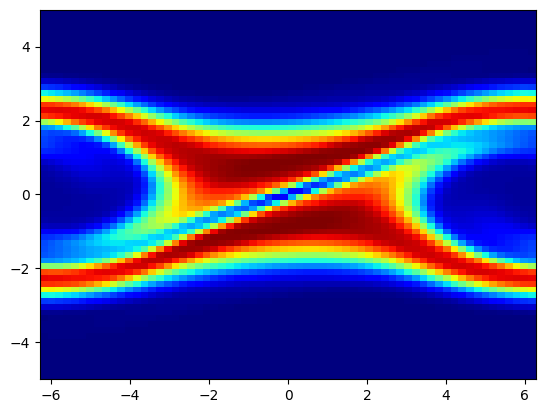

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# User-set parameters
## Spatial grid
xoff=2
voff=2
xmesh=64
vmesh=64
nx=xmesh+2*xoff
nv=vmesh+2*voff
## Domain size and CFL number
lx=4.0*np.pi                          # X domain, [-lx/2,lx/2]
lv=5.0                          # V domain, [-lv,lv]
cfl=0.2
## Simulation time
tmax=16.0
# Normalized charge
q=-1.0                          # -1 for electrons
## Perturbation
amp=0.05                        # Perturbation amplitude
kk=0.5                       # Perturbation wavenumber
vd=1.5                       # Drift velocity for two-stream instability
vs=0.5                       # Thermal velocity for two-stream instability
# End of user-set parameters

# Grid width
dx=lx/xmesh
dv=2*lv/vmesh
dt=np.abs(cfl*dx/lv)
# Variables
x=np.zeros(nx)
v=np.zeros(nv)
f=np.zeros((nv,nx))
g=np.zeros(nx)
drho=np.zeros(nx)

# Functions
def gaussian(x,a,b):
    return np.exp(-0.5*((x-a)/b)**2) / (b*np.sqrt(2*np.pi))

def init(x,v,f):                  # Initialize
    nv,nx=f.shape
    i=np.arange(nx)
    j=np.arange(nv)
    x[:]=(i+0.5-xoff)*dx-0.5*lx
    v[:]=(j+0.5-voff)*dv-lv
    # fv=gaussian(v,0,1.0)
    fv=0.5*(gaussian(v,+vd,vs)+gaussian(v,-vd,vs)) # Two-stream instability
    fx=1.0+amp*np.cos(kk*x)
    f[:,:]=fv[:,None]*fx[None,:]

def bc2d(f,xoff,yoff,dnx=0,dny=0): # Boundary condition
    # f : shape (ny,nx)
    # dnx, dny: 0 (periodic), +-1 (free of fix)
    ny, nx = f.shape
    # ---- x direction ----
    if dnx == 0:
        f[:, :xoff]      = f[:, nx-2*xoff:nx-xoff]
        f[:, nx-xoff:]   = f[:, xoff:2*xoff]
    elif abs(dnx) == 1:
        f[:, :xoff] = dnx * f[:, xoff:2*xoff][:, ::-1] # Left
        f[:, nx-xoff:] = dnx * f[:, nx-2*xoff:nx-xoff][:, ::-1] # Right
    # ---- y direction ----
    if dny == 0:
        f[:yoff, :]      = f[ny-2*yoff:ny-yoff, :]
        f[ny-yoff:, :]   = f[yoff:2*yoff, :]
    elif abs(dny) == 1:
        f[:yoff, :] = dny * f[yoff:2*yoff, :][::-1, :] # Bottom
        f[ny-yoff:, :] = dny * f[ny-2*yoff:ny-yoff, :][::-1, :] # Top

def minmod(a,b):
    return np.where(a*b < 0, 0, np.where(np.abs(a) < np.abs(b), a, b))
def mm3(a,b,c):
    return minmod(minmod(a,b),c)
def cslmsl(f,v,dt,dx,xoff=2):       # Conservative SL-MUSCL scheme
    nx=len(f)
    nu=v*dt/dx
    sgnv=np.sign(v)
    flux=np.zeros_like(f)
    c0l=(-f[0:-3]+5*f[1:-2]+2*f[2:-1])/6.0
    c0r=(-f[3:  ]+5*f[2:-1]+2*f[1:-2])/6.0
    c1 =f[2:-1]-f[1:-2]
    c2l=(f[0:-3]-2*f[1:-2]+f[2:-1])*0.5
    c2r=(f[3:  ]-2*f[2:-1]+f[1:-2])*0.5
    ftl=c0l+nu*(-c1*0.5+c2l*nu/3.0)
    ftr=c0r+nu*(-c1*0.5+c2r*nu/3.0)
    slope_l=mm3(f[1:-2]-f[0:-3],f[2:-1]-f[1:-2],ftl-f[1:-2])
    slope_r=mm3(f[2:-1]-f[1:-2],f[3:  ]-f[2:-1],f[2:-1]-ftr)
    flux[2:-1]=0.5*((1+sgnv)*(f[1:-2]+slope_l)+(1-sgnv)*(f[2:-1]-slope_r))
    f[xoff:nx-xoff]-=nu*(flux[xoff+1:nx-xoff+1]-flux[xoff:nx-xoff])

def csl3rd(f,v,dt,dx,xoff=2):       # 3rd-order conservative semi-Lagrangian scheme
    nx=len(f)
    nu=v*dt/dx
    sgnv=np.sign(v)
    flux=np.zeros_like(f)
    c0l=(-f[0:-3]+5*f[1:-2]+2*f[2:-1])/6.0
    c0r=(-f[3:  ]+5*f[2:-1]+2*f[1:-2])/6.0
    c1 =f[2:-1]-f[1:-2]
    c2l=(f[0:-3]-2*f[1:-2]+f[2:-1])*0.5
    c2r=(f[3:  ]-2*f[2:-1]+f[1:-2])*0.5
    ftl=c0l+nu*(-c1*0.5+c2l*nu/3.0)
    ftr=c0r+nu*(-c1*0.5+c2r*nu/3.0)
    flux[2:-1]=0.5*((1+sgnv)*ftl+(1-sgnv)*ftr)
    f[xoff:nx-xoff]-=nu*(flux[xoff+1:nx-xoff+1]-flux[xoff:nx-xoff])

def pushx(f,v,dt,dx,xoff=2,voff=2):
    bc2d(f,xoff,voff,0,999) # Periodic in X, nothing to do in V
    for fi,vi in zip(f[voff:-voff,:],v[voff:-voff]):
        cslmsl(fi,vi,dt,dx,xoff)

def pushv(f,g,dt,dv,xoff=2,voff=2):
    nv,nx=f.shape
    for i in range(xoff,nx-xoff):
        ftmp = f[:, i].copy()
        cslmsl(ftmp, 0.5*(g[i]+g[i+1]), dt, dv, voff)
        f[voff:nv-voff, i] = ftmp[voff:nv-voff]

def main(t,tmax):
    while(t < tmax):
        # Advection in X (half)
        pushx(f,v,0.5*dt,dx,xoff,voff)

        # Calculate density fluctuation
        drho[xoff:-xoff]=np.sum(f[voff:-voff,xoff:-xoff],axis=0)*dv
        dmean=np.sum(drho[xoff:-xoff])*dx/lx
        drho[xoff:-xoff]-=dmean

        # Calculate electric field
        g[xoff]=0.0
        for i in range(xoff+1,nx-xoff+1):
            g[i]=g[i-1]+q*drho[i-1]*dx
        gmean=np.sum(0.5*(g[xoff:nx-xoff]+g[xoff+1:nx-xoff+1]))*dx/lx
        g[xoff:nx-xoff+1]-=gmean

        # Advection in V (full)
        pushv(f,q*g,  dt,dv,xoff,voff)

        # Advection in X (half)
        pushx(f,v,0.5*dt,dx,xoff,voff)

        t+=dt
    return t

init(x,v,f)
t=main(0,tmax)
print(f"Simulation end at t = {t:.6f}")
plt.imshow(f[voff:-voff,xoff:-xoff],cmap='jet',origin='lower',aspect='auto',extent=[-lx/2,lx/2,-lv,lv])
plt.show()


In [2]:
print,np.min(f)

(<function print(*args, sep=' ', end='\n', file=None, flush=False)>,
 np.float64(2.9221641677849745e-13))